# Shower-energy heatmap over the mountain

Quick visual sanity check: across all 20 000 cached training showers, where on the
mountain (in the `(North, Up)` plane) do showers actually deposit energy?

**Detectors are intentionally ignored here** — this is a pure shower-distribution view.

In [29]:
import sys, os
import numpy as np
import torch
import showerdata
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

_tests_dir = os.path.dirname(os.path.abspath('__file__'))
_v4_root   = os.path.normpath(os.path.join(_tests_dir, '..'))
if _v4_root not in sys.path:
    sys.path.insert(0, _v4_root)

import modules_v4  # triggers sys.path injection for v3
from modules_v4.tr_geometry import load_tr_mountain

GEOMETRY_PATH = '../../../TAMBOSim/resources/basic_geometry.h5'
print('OK')

OK


## Load mountain

In [30]:
mountain = load_tr_mountain(GEOMETRY_PATH, 'colca_valley_30000', 'detector1',
                            east_entry=-212.0, layer_east_dx=307.0, n_planes=24)
print(f"Mountain bbox: N=[{mountain.n_min:.0f}, {mountain.n_max:.0f}] m  "
      f"Up=[{mountain.u_min:.0f}, {mountain.u_max:.0f}] m  "
      f"East=[{mountain.east_lo:.0f}, {mountain.east_hi:.0f}] m")

Mountain bbox: N=[-2497, 2474] m  Up=[2442, 3886] m  East=[-2019, 1182] m


## Load cached 20 000 showers

In [31]:
candidate_paths = [
    '../outputs/NN_Files_35_20k_clamp_detectors/cashed_showers_20000.pt',
    '../outputs/NN_Files_34_20k/cashed_showers_20000.pt',
]
shower_path = next((p for p in candidate_paths if os.path.exists(p)), None)
if shower_path is None:
    raise FileNotFoundError(f'No cached 20k shower file found.  Tried: {candidate_paths}')
print(f'Loading: {shower_path}')

sh         = showerdata.load(shower_path)
samples    = torch.tensor(sh.points)        # (N, max_points, 5)
energies   = torch.tensor(sh.energies)
directions = torch.tensor(sh.directions)
labels     = torch.tensor(sh.pdg)

print(f'samples:    {tuple(samples.shape)}     dtype={samples.dtype}')
print(f'energies:   {tuple(energies.shape)}')
print(f'directions: {tuple(directions.shape)}')
print(f'labels:     {tuple(labels.shape)}')

Loading: ../outputs/NN_Files_35_20k_clamp_detectors/cashed_showers_20000.pt


samples:    (20000, 2048, 5)     dtype=torch.float32
energies:   (20000, 1)
directions: (20000, 3)
labels:     (20000,)


## Flatten and drop padding (`energy == 0`)

In [32]:
# samples columns: [x=North, y=Up, layer_index, energy, time]
# Restrict to AllShowers layers whose East range overlaps the mountain surface.
# z_cont_max = (east_entry - east_lo) / layer_east_dx ~ 5.9, so layers 0..6.
max_layer = int(np.ceil(mountain.east_to_z_cont(mountain.east_lo)))
print(f'Mountain accessible layers: 0..{max_layer}  '
      f'(z_cont_max = {mountain.east_to_z_cont(mountain.east_lo):.2f})')

flat = samples.reshape(-1, 5)
mask = (flat[:, 3] > 0) & (flat[:, 2] >= 0) & (flat[:, 2] <= max_layer)
x_all = flat[mask, 0].numpy()   # North
y_all = flat[mask, 1].numpy()   # Up
layer = flat[mask, 2].numpy()
e_all = flat[mask, 3].numpy()   # energy

# ── Recenter showers vertically ────────────────────────────────────────────
# AllShowers fixture is centred around its own Up mean; shift it so the
# energy-weighted shower centre lands lower in the (N, Up) plane.  Adjust
# Y_TARGET to move the centre up/down.
Y_TARGET   = mountain.u_min + 0.25 * (mountain.u_max - mountain.u_min)
y_centroid = float(np.average(y_all, weights=e_all))
y_shift    = Y_TARGET - y_centroid
y_all      = y_all + y_shift
print(f'Shower energy centroid (Up): {y_centroid:.0f} m  →  shifted by {y_shift:+.0f} m  '
      f'→  new centre {Y_TARGET:.0f} m')

print(f'Total shower points (non-padding, layers 0..{max_layer}): {len(x_all):,}')
print(f'Total energy:                                              {e_all.sum():.3e}')
print(f'North range: [{x_all.min():.0f}, {x_all.max():.0f}] m')
print(f'Up range:    [{y_all.min():.0f}, {y_all.max():.0f}] m')
print(f'Energy:      mean={e_all.mean():.3f}  max={e_all.max():.3f}')

Mountain accessible layers: 0..6  (z_cont_max = 5.89)
Shower energy centroid (Up): -494 m  →  shifted by +3297 m  →  new centre 2803 m
Total shower points (non-padding, layers 0..6): 2,927,772
Total energy:                                              4.494e+11
North range: [-10011, 11896] m
Up range:    [-6889, 13624] m
Energy:      mean=153511.609  max=401772896.000


## Heatmaps — energy-weighted vs raw point density

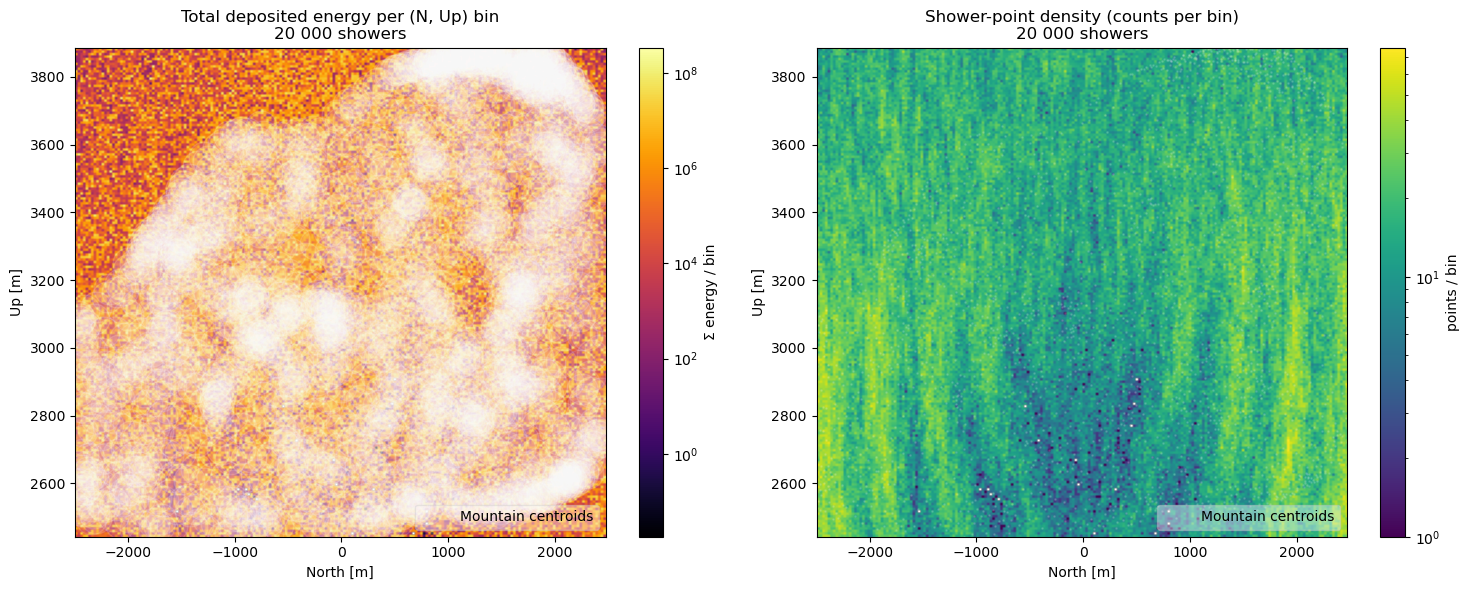

In [33]:
bins   = (200, 200)
extent = [mountain.n_min, mountain.n_max, mountain.u_min, mountain.u_max]
range_ = [[mountain.n_min, mountain.n_max], [mountain.u_min, mountain.u_max]]

H_e, _, _ = np.histogram2d(x_all, y_all, bins=bins, range=range_, weights=e_all)
H_n, _, _ = np.histogram2d(x_all, y_all, bins=bins, range=range_)

# Mountain centroids for context
N_mtn  = mountain.centroids_NUE[:, 0]
Up_mtn = mountain.centroids_NUE[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

im0 = axes[0].imshow(H_e.T, origin='lower', extent=extent, aspect='auto',
                     cmap='inferno', norm=LogNorm(vmin=max(H_e[H_e > 0].min(), 1e-3),
                                                  vmax=H_e.max()))
axes[0].scatter(N_mtn, Up_mtn, s=500, c='white', alpha=0.12, label='Mountain centroids')
axes[0].set_title('Total deposited energy per (N, Up) bin\n20 000 showers')
axes[0].set_xlabel('North [m]'); axes[0].set_ylabel('Up [m]')
axes[0].legend(loc='lower right', framealpha=0.4)
fig.colorbar(im0, ax=axes[0], label='\u03a3 energy / bin')

im1 = axes[1].imshow(H_n.T, origin='lower', extent=extent, aspect='auto',
                     cmap='viridis', norm=LogNorm(vmin=max(H_n[H_n > 0].min(), 1),
                                                  vmax=H_n.max()))
axes[1].scatter(N_mtn, Up_mtn, s=1, c='white', alpha=0.12, label='Mountain centroids')
axes[1].set_title('Shower-point density (counts per bin)\n20 000 showers')
axes[1].set_xlabel('North [m]'); axes[1].set_ylabel('Up [m]')
axes[1].legend(loc='lower right', framealpha=0.4)
fig.colorbar(im1, ax=axes[1], label='points / bin')

plt.tight_layout(); plt.show()

## Layer occupancy (sanity)

Should be concentrated in AllShowers layers 0–6 — those are the only layers whose East
values overlap the mountain's East range `[-2019, +1182] m`.

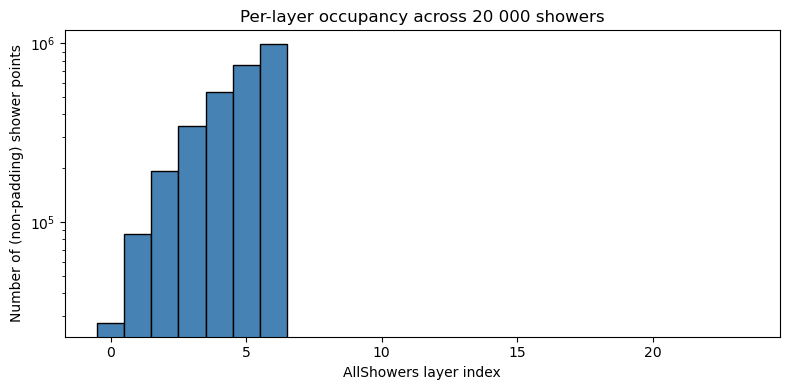

In [34]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(layer, bins=np.arange(-0.5, 24.5, 1), color='steelblue', edgecolor='k')
ax.set_xlabel('AllShowers layer index')
ax.set_ylabel('Number of (non-padding) shower points')
ax.set_title('Per-layer occupancy across 20 000 showers')
ax.set_yscale('log')
plt.tight_layout(); plt.show()